In [1]:
# Cell 0 — same in every notebook
import os
os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: c:\Users\asdaw\Desktop\Projects\ProductReviewAI


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

print("All imports successful")

c:\Users\asdaw\anaconda3\envs\product_review_ai\lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


All imports successful


In [3]:
conn = sqlite3.connect("data/reviews.db")
df = pd.read_sql("SELECT * FROM reviews_clean", conn)
conn.close()

print(f"Loaded: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSentiment distribution:")
print(df["sentiment"].value_counts())

Loaded: 86,738 rows
Columns: ['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'review_length', 'title_length', 'month', 'year', 'sentiment', 'full_text']

Sentiment distribution:
sentiment
1    74723
0    12015
Name: count, dtype: int64


In [ ]:
# build TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    strip_accents="unicode",
    stop_words="english"
)

X = vectorizer.fit_transform(df["text"])
y = df["sentiment"].values # no index or column name, just the values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive: {y.sum():,}  Negative: {(y==0).sum():,}")

# split into train and test
# 80% for training, 20% for testing
# random_state=42 means same split every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps same 86:14 ratio in both train and test
)

print(f"\nTrain size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

X shape: (86738, 5000)
y shape: (86738,)
Positive: 74,723  Negative: 12,015

Train size: 69,390
Test size:  17,348


In [ ]:
# we will call this function for every model
# so we don't repeat the same code 3 times

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # some models don't have predict_proba
    # LinearSVC uses decision_function instead
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    
    metrics = {
        "model":     name,
        "accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred), 4),
        "recall":    round(recall_score(y_test, y_pred), 4),
        "f1":        round(f1_score(y_test, y_pred), 4),
        "roc_auc":   round(roc_auc_score(y_test, y_prob), 4),
    }
    
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    for k, v in metrics.items():
        if k != "model":
            print(f"  {k:12} {v}")
    
    return metrics, y_pred

In [7]:
mlflow.set_experiment("sentiment_analysis")

with mlflow.start_run(run_name="LogisticRegression"):
    
    model_lr = LogisticRegression(
        class_weight="balanced",  # handles 86:14 imbalance
        max_iter=1000,
        random_state=42
    )
    model_lr.fit(X_train, y_train)
    
    metrics_lr, pred_lr = evaluate_model(
        "Logistic Regression", model_lr, X_test, y_test
    )
    
    # log to mlflow
    mlflow.log_params({"model": "LogisticRegression",
                       "class_weight": "balanced",
                       "max_features": 5000})
    mlflow.log_metrics({k: v for k, v in metrics_lr.items() if k != "model"})
    mlflow.sklearn.log_model(model_lr, "model")

print("Logistic Regression done")

2026/06/29 16:24:33 INFO mlflow.tracking.fluent: Experiment with name 'sentiment_analysis' does not exist. Creating a new experiment.



  Logistic Regression
  accuracy     0.8975
  precision    0.9765
  recall       0.9027
  f1           0.9382
  roc_auc      0.951
Logistic Regression done


In [8]:
with mlflow.start_run(run_name="RandomForest"):
    
    model_rf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1        # use all CPU cores
    )
    model_rf.fit(X_train, y_train)
    
    metrics_rf, pred_rf = evaluate_model(
        "Random Forest", model_rf, X_test, y_test
    )
    
    mlflow.log_params({"model": "RandomForest",
                       "n_estimators": 100,
                       "class_weight": "balanced"})
    mlflow.log_metrics({k: v for k, v in metrics_rf.items() if k != "model"})
    mlflow.sklearn.log_model(model_rf, "model")

print("Random Forest done")


  Random Forest
  accuracy     0.9172
  precision    0.925
  recall       0.9835
  f1           0.9534
  roc_auc      0.9329
Random Forest done


In [10]:
with mlflow.start_run(run_name="XGBoost"):
    
    # scale_pos_weight handles imbalance in XGBoost
    # = number of negative samples / number of positive samples
    scale = (y_train == 1).sum() / (y_train == 0).sum()  # 6.2
    print(f"scale_pos_weight: {scale:.2f}")
    
    model_xgb = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    )
    model_xgb.fit(X_train, y_train)
    
    metrics_xgb, pred_xgb = evaluate_model(
        "XGBoost", model_xgb, X_test, y_test
    )
    
    mlflow.log_params({"model": "XGBoost",
                       "n_estimators": 100,
                       "scale_pos_weight": round(scale, 2)})
    mlflow.log_metrics({k: v for k, v in metrics_xgb.items() if k != "model"})
    mlflow.sklearn.log_model(model_xgb, "model")

print("XGBoost done")

scale_pos_weight: 6.22

  XGBoost
  accuracy     0.9011
  precision    0.9002
  recall       0.9956
  f1           0.9455
  roc_auc      0.9324
XGBoost done


                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.8975     0.9765  0.9027  0.9382   0.9510
Random Forest          0.9172     0.9250  0.9835  0.9534   0.9329
XGBoost                0.9011     0.9002  0.9956  0.9455   0.9324


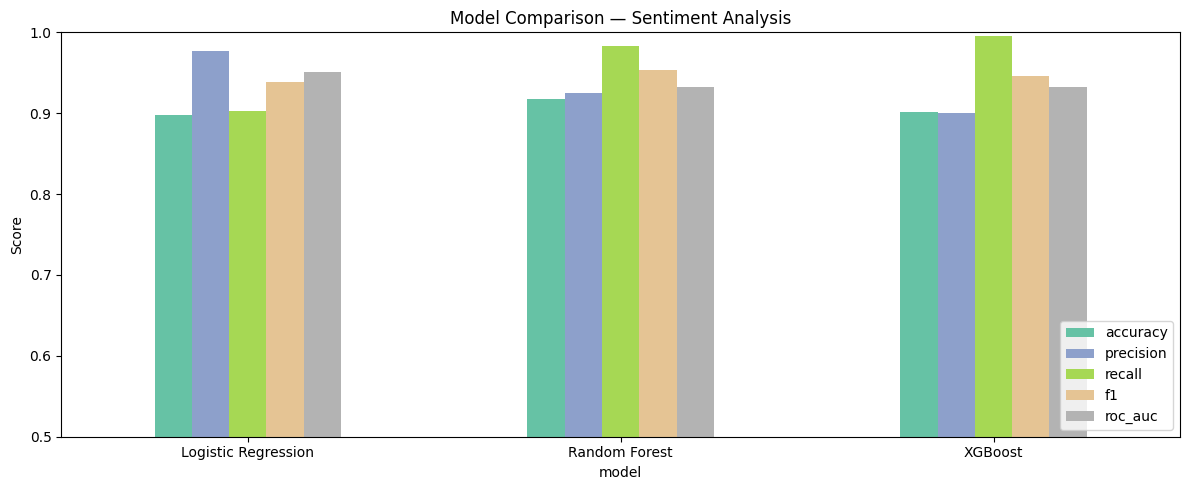

In [11]:
results = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb])
results = results.set_index("model")
print(results)

# bar chart comparison
results[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(12, 5), colormap="Set2"
)
plt.title("Model Comparison — Sentiment Analysis")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

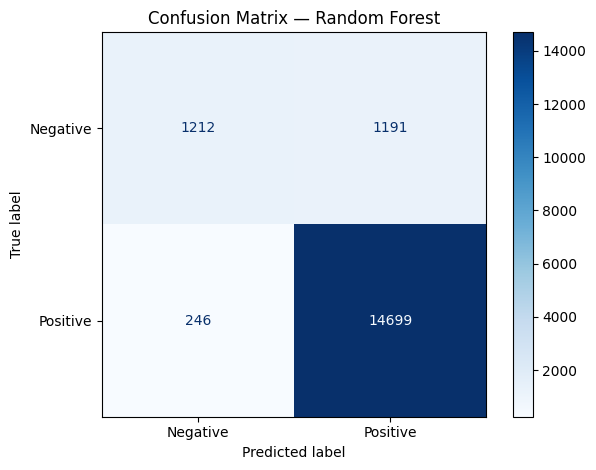


True Negative  (correctly predicted negative): 1,212
False Positive (predicted positive, was negative): 1,191
False Negative (predicted negative, was positive): 246
True Positive  (correctly predicted positive): 14,699


In [12]:
# after seeing results pick the best model
# most likely XGBoost or Logistic Regression

best_model  = model_rf   # change this after seeing results
best_pred   = pred_rf
best_name   = "Random Forest"

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# explain what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (correctly predicted negative): {tn:,}")
print(f"False Positive (predicted positive, was negative): {fp:,}")
print(f"False Negative (predicted negative, was positive): {fn:,}")
print(f"True Positive  (correctly predicted positive): {tp:,}")

In [13]:
import os

os.makedirs("../models", exist_ok=True)

# save best model
with open("../models/sentiment_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# save vectorizer
with open("../models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Saved → models/sentiment_model.pkl")
print("Saved → models/tfidf_vectorizer.pkl")

Saved → models/sentiment_model.pkl
Saved → models/tfidf_vectorizer.pkl


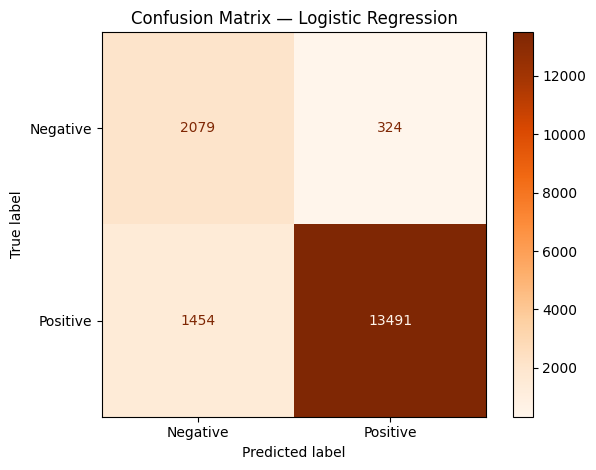


True Negative:  2,079
False Positive: 324
False Negative: 1,454
True Positive:  13,491


In [14]:
cm_lr = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=["Negative", "Positive"])
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"\nTrue Negative:  {tn:,}")
print(f"False Positive: {fp:,}")
print(f"False Negative: {fn:,}")
print(f"True Positive:  {tp:,}")

In [15]:
best_model = model_lr
best_pred  = pred_lr
best_name  = "Logistic Regression"

print("Best model: Logistic Regression")
print("Reason: lowest False Positives (324 vs 1191)")
print("Business logic: missing real complaints is more costly")
print("than investigating false alarms")

Best model: Logistic Regression
Reason: lowest False Positives (324 vs 1191)
Business logic: missing real complaints is more costly
than investigating false alarms


Model selection reasoning:

Random Forest has higher F1 (0.9534) but 1,191 False Positives.
Logistic Regression has lower F1 (0.9382) but only 324 False Positives.

For sentiment analysis in a retail context, False Positives
(missing real negative reviews) are more costly than False Negatives.
A missed complaint = unresolved customer issue = potential churn.
A false alarm = unnecessary investigation = minor inefficiency.

Therefore Logistic Regression is selected as the production model
despite lower F1 score. Business context drives model selection,
not just metrics.

In [16]:
import os
os.makedirs("models", exist_ok=True)

with open("models/sentiment_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Saved → models/sentiment_model.pkl")
print("Saved → models/tfidf_vectorizer.pkl")

Saved → models/sentiment_model.pkl
Saved → models/tfidf_vectorizer.pkl
